# Семинар 4. Как работают градиентные методы

**30.09.2026. Машинное обучение, ФТиАД.**

На семинаре 3 мы сравнили полный градиент, mini-batch и SGD. Теперь проследим, куда попадают веса после каждого обновления. Начнём с длины шага, затем посмотрим на Momentum, AdaGrad, RMSprop и Adam на функции с двумя весами. В конце обучим этими пятью методами спам-фильтр на одних и тех же письмах и сравним скорость сходимости и ошибки.

In [55]:
import base64
import gzip
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
np.set_printoptions(precision=3, suppress=True)

## 1. Что меняет длина шага

Возьмём $F(w)=w^2$. Производная равна $F'(w)=2w$, поэтому один шаг GD имеет вид $w_{t+1}=w_t-2\eta w_t$. Стартуем из $w_0=3$.

**Перед запуском:** посчитайте $w_1$ для $\eta=0.1$, $0.6$ и $1.1$. Для какого шага мы перескочим через минимум? Можно ли перескочить и всё же приблизиться к нему?

w_t               F(w_t)               
η        0.1    0.6    1.1    0.1    0.6     1.1
Шаг t                                           
0      3.000  3.000  3.000  9.000  9.000   9.000
1      2.400 -0.600 -3.600  5.760  0.360  12.960
2      1.920  0.120  4.320  3.686  0.014  18.662
3      1.536 -0.024 -5.184  2.359  0.001  26.874

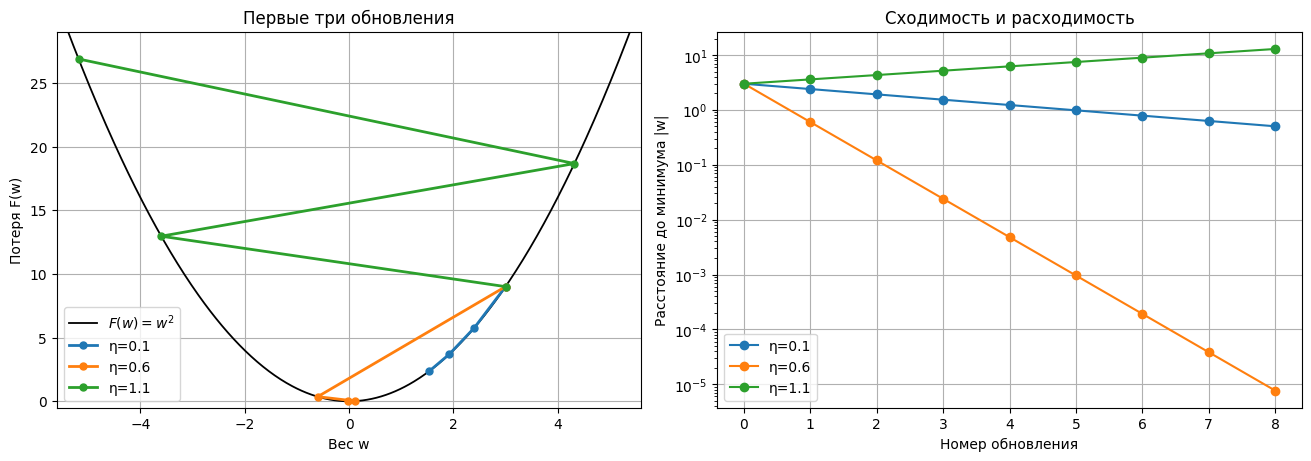

In [56]:
def one_dim_path(eta, steps=8):
    path = [3.0]
    for _ in range(steps):
        path.append(path[-1] - eta * 2 * path[-1])
    return np.array(path)

etas = [0.1, 0.6, 1.1]
paths_1d = {eta: one_dim_path(eta) for eta in etas}
rows = []
for eta, path in paths_1d.items():
    for t in range(4):
        rows.append({'η': eta, 'Шаг t': t, 'w_t': path[t], 'F(w_t)': path[t] ** 2})
display(pd.DataFrame(rows).round(3).pivot(index='Шаг t', columns='η', values=['w_t', 'F(w_t)']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout='constrained')
axis_w = np.linspace(-5.6, 5.6, 500)
axes[0].plot(axis_w, axis_w ** 2, color='black', lw=1.3, label='$F(w)=w^2$')
for eta, color in [(0.1, 'tab:blue'), (0.6, 'tab:orange'), (1.1, 'tab:green')]:
    path = paths_1d[eta][:4]
    axes[0].plot(path, path ** 2, 'o-', color=color, lw=2, ms=5, label=f'η={eta}', zorder=3)
axes[0].set(xlabel='Вес w', ylabel='Потеря F(w)', title='Первые три обновления',
            xlim=(-5.6, 5.6), ylim=(-0.5, 29))
axes[0].legend()
for eta, path in paths_1d.items():
    axes[1].semilogy(range(len(path)), np.abs(path), 'o-', label=f'η={eta}')
axes[1].set(xlabel='Номер обновления', ylabel='Расстояние до минимума |w|', title='Сходимость и расходимость')
axes[1].legend()
plt.show()

При $\eta=0.6$ вес меняет знак, но расстояние до нуля уменьшается. При $\eta=1.1$ вес тоже меняет знак, однако удаляется от минимума. Из формулы $w_{t+1}=(1-2\eta)w_t$ видно, что для этой функции сходимость из ненулевой точки есть при $0<\eta<1$.

**Проверьте себя:** что произойдёт при $\eta=1$? Сначала предскажите результат по формуле, затем поменяйте одно значение в списке `etas` и повторите ячейку.

## 2. Что добавляет Momentum к GD

Рассмотрим функцию $F(w_1,w_2)=\frac12(w_1^2+25w_2^2)$. Её минимум находится в $(0,0)$, а градиент равен $(w_1,25w_2)$. По второму весу поверхность круче, поэтому он легко перескакивает через ноль.

Здесь **на каждом шаге считается полный градиент** этой функции. Случайного выбора объектов нет. Обычный GD делает обновление $w_{t+1}=w_t-\eta\nabla F(w_t)$. Momentum дополнительно хранит скорость: $v_t=\beta v_{t-1}+\nabla F(w_t)$, затем $w_{t+1}=w_t-\eta v_t$.

Верхний график показывает первые 10 изменений второго веса. Средний график показывает **все 45 шагов** на эллипсах линий уровня: каждый серый эллипс соединяет точки с одинаковой потерей $F$. Чёрный квадрат отмечает начальную точку, звезда отмечает минимум, цветные кружки отмечают точки после 45 шагов. Нижний график показывает потерю за те же 45 обновлений. Стартовая потеря равна 31.25, к шагу 45 она снижается примерно до 0.012 у GD и 0.00095 у Momentum. Поэтому колебания первых шагов не означают отсутствия сходимости. Для наглядности взяты $\eta=0.06$ у GD и $\eta=0.04$, $\beta=0.5$ у Momentum. Это пример работы правил обновления при разных настройках, а не соревнование за лучший метод.

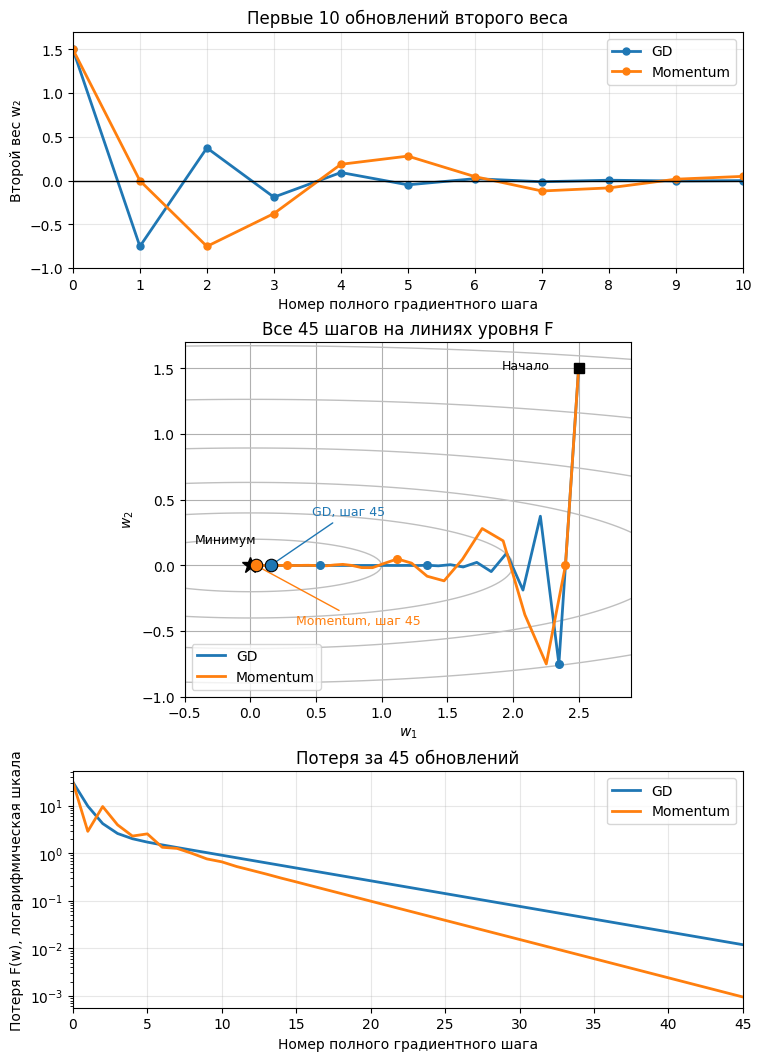

GD: F(0)=31.2500, F(10)=0.9066, F(45)=0.0119
Momentum: F(0)=31.2500, F(10)=0.6583, F(45)=0.0009


In [57]:
def bowl(w):
    return 0.5 * (w[0] ** 2 + 25 * w[1] ** 2)

def bowl_grad(w):
    return np.array([w[0], 25 * w[1]])

def gd_bowl(eta, steps=45):
    w = np.array([2.5, 1.5])
    path = [w.copy()]
    for _ in range(steps):
        w = w - eta * bowl_grad(w)
        path.append(w.copy())
    return np.array(path)

def momentum_bowl(eta, beta=0.5, steps=45):
    w = np.array([2.5, 1.5])
    velocity = np.zeros(2)
    path = [w.copy()]
    for _ in range(steps):
        velocity = beta * velocity + bowl_grad(w)
        w = w - eta * velocity
        path.append(w.copy())
    return np.array(path)

gd_2d = gd_bowl(eta=0.06)
momentum_2d = momentum_bowl(eta=0.04, beta=0.5)

fig, axes = plt.subplots(3, 1, figsize=(7.5, 10.5), layout='constrained',
                         gridspec_kw={'height_ratios': [1, 1.5, 1]})
methods = [('GD', gd_2d, 'tab:blue'),
           ('Momentum', momentum_2d, 'tab:orange')]
for name, path, color in methods:
    axes[0].plot(np.arange(11), path[:11, 1], 'o-', ms=5, lw=2,
                 color=color, label=name)
    axes[2].semilogy([bowl(w) for w in path], lw=2, color=color, label=name)
axes[0].axhline(0, color='black', lw=1)
axes[0].set(xlim=(0, 10), xticks=np.arange(11), ylim=(-1.0, 1.7),
            xlabel='Номер полного градиентного шага', ylabel='Второй вес w₂',
            title='Первые 10 обновлений второго веса')

xx, yy = np.meshgrid(np.linspace(-3, 3, 300),
                     np.linspace(-1.8, 1.8, 240))
zz = 0.5 * (xx ** 2 + 25 * yy ** 2)
axes[1].contour(xx, yy, zz, levels=[0.5, 2, 5, 10, 20, 35],
                colors='0.75', linewidths=1)
for name, path, color in methods:
    axes[1].plot(path[:, 0], path[:, 1], '-', lw=2,
                 color=color, label=name)
    axes[1].scatter(path[[1, 10, 25], 0], path[[1, 10, 25], 1],
                    color=color, s=30, zorder=3)
    axes[1].plot(path[-1, 0], path[-1, 1], 'o', ms=9, color=color, mec='black', mew=0.8, zorder=5)
axes[1].plot(2.5, 1.5, 'ks', ms=7)
axes[1].text(2.28, 1.52, 'Начало', ha='right', va='center', fontsize=9)
axes[1].plot(0, 0, 'k*', ms=12)
axes[1].text(-0.42, 0.17, 'Минимум', ha='left', fontsize=9)
axes[1].annotate('GD, шаг 45', xy=gd_2d[-1], xytext=(0.47, 0.38),
                 arrowprops={'arrowstyle': '-', 'color': 'tab:blue'}, color='tab:blue', fontsize=9)
axes[1].annotate('Momentum, шаг 45', xy=momentum_2d[-1], xytext=(0.35, -0.45),
                 arrowprops={'arrowstyle': '-', 'color': 'tab:orange'}, color='tab:orange', fontsize=9)
axes[1].set(xlim=(-0.5, 2.9), ylim=(-1.0, 1.7), xlabel='$w_1$', ylabel='$w_2$',
            title='Все 45 шагов на линиях уровня F')
axes[1].set_aspect('equal', adjustable='box')
axes[1].legend(loc='lower left')

axes[2].set(xlim=(0, 45), xlabel='Номер полного градиентного шага',
            ylabel='Потеря F(w), логарифмическая шкала',
            title='Потеря за 45 обновлений')
axes[0].legend()
axes[2].legend()
axes[0].grid(alpha=0.3)
axes[2].grid(alpha=0.3)
plt.show()
for name, path, _ in methods:
    print(f'{name}: F(0)={bowl(path[0]):.4f}, F(10)={bowl(path[10]):.4f}, F(45)={bowl(path[45]):.4f}')


После первого шага Momentum второй вес равен нулю. На следующем шаге текущая производная по этому весу тоже равна нулю, но сохранённая скорость ещё равна $0.5\cdot37.5=18.75$. Поэтому обновление переносит вес из $0$ в $-0.75$. Это **инерция**, а не шум от случайных объектов.

На верхнем графике колебания полностью определяются формулой и начальной точкой. На нижнем видно, что потеря Momentum может временно вырасти после шага, а затем продолжить снижение. При этих настройках к 45-му обновлению она меньше, чем у показанного GD. Из одного примера нельзя сделать вывод, что Momentum всегда лучше.

**Проверка:** задайте $\beta=0$ в вызове `momentum_bowl`. Получится обычный GD с тем же $\eta=0.04$. Сравните его путь с оранжевой линией.

## 3. Как избежать слишком большого шага

Вернёмся к вытянутой поверхности из предыдущего блока. В точке $(2.5, 1.5)$ градиент равен $(2.5, 37.5)$. По второму весу функция гораздо круче, поэтому его изменение при обычном GD получается большим.

Возьмём $\eta=0.1$. GD меняет второй вес с $1.5$ на $-2.25$: перескакивает через минимум, а потеря растёт с $31.25$ до $65.81$. Если уменьшить $\eta$, GD тоже сможет спускаться. Сейчас посмотрим на другой способ уменьшить опасный шаг.

AdaGrad хранит историю квадратов градиентов **отдельно для каждого веса** и делит очередной градиент на корень из этой суммы. На первом шаге история состоит только из текущего градиента. Поэтому каждый вес меняется примерно на $0.1$: точка $(2.5,1.5)$ переходит в $(2.4,1.4)$, а потеря снижается до $27.38$. Это один пример обновления, а не доказательство преимущества AdaGrad в любой задаче.

На рисунке серая полоса показывает потерю $F(2.5,1.5)$ **до любого обновления**. Синяя и оранжевая полосы показывают потерю после одного шага GD и AdaGrad. Потеря зависит от обоих весов. Ниже сравним длинные траектории AdaGrad, RMSprop и Adam.

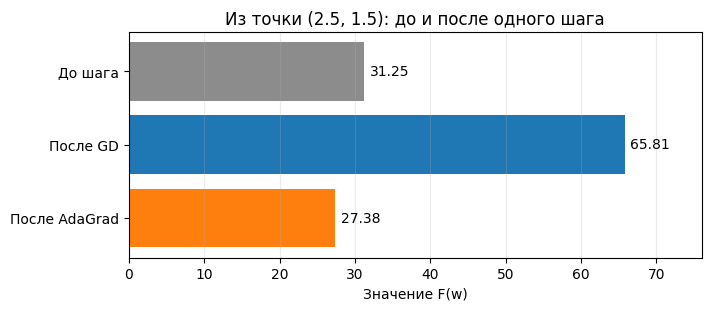

In [58]:
start = np.array([2.5, 1.5])
eta_example = 0.1
grad_start = bowl_grad(start)
gd_next = start - eta_example * grad_start
adagrad_next = start - eta_example * grad_start / (np.abs(grad_start) + 1e-8)

labels = ['До шага', 'После GD', 'После AdaGrad']
losses = [bowl(start), bowl(gd_next), bowl(adagrad_next)]
fig, ax = plt.subplots(figsize=(7, 3), layout='constrained')
bars = ax.barh(labels, losses, color=['0.55', 'tab:blue', 'tab:orange'])
ax.bar_label(bars, fmt='%.2f', padding=4)
ax.invert_yaxis()
ax.set(xlabel='Значение F(w)', xlim=(0, 76),
       title='Из точки (2.5, 1.5): до и после одного шага')
ax.grid(axis='x', alpha=0.25)
ax.grid(axis='y', visible=False)
plt.show()

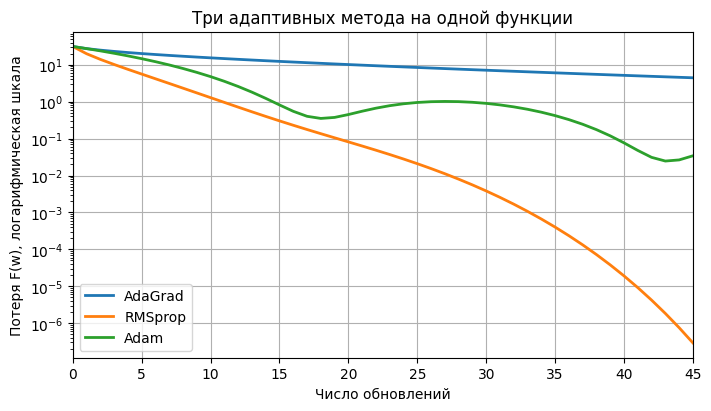

In [59]:
def adaptive_bowl(method, eta=0.1, steps=45):
    w = np.array([2.5, 1.5])
    mean_grad = np.zeros(2)
    mean_square = np.zeros(2)
    square_sum = np.zeros(2)
    path = [w.copy()]
    for t in range(1, steps + 1):
        grad = bowl_grad(w)
        if method == 'AdaGrad':
            square_sum += grad ** 2
            update = eta * grad / (np.sqrt(square_sum) + 1e-8)
        elif method == 'RMSprop':
            mean_square = 0.9 * mean_square + 0.1 * grad ** 2
            update = eta * grad / (np.sqrt(mean_square) + 1e-8)
        elif method == 'Adam':
            mean_grad = 0.9 * mean_grad + 0.1 * grad
            mean_square = 0.999 * mean_square + 0.001 * grad ** 2
            corrected_grad = mean_grad / (1 - 0.9 ** t)
            corrected_square = mean_square / (1 - 0.999 ** t)
            update = eta * corrected_grad / (np.sqrt(corrected_square) + 1e-8)
        else:
            raise ValueError(method)
        w = w - update
        path.append(w.copy())
    return np.array(path)

adaptive_paths = {name: adaptive_bowl(name) for name in ['AdaGrad', 'RMSprop', 'Adam']}
fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
for name, path in adaptive_paths.items():
    ax.semilogy([bowl(w) for w in path], lw=2, label=name)
ax.set(xlabel='Число обновлений', ylabel='Потеря F(w), логарифмическая шкала',
       title='Три адаптивных метода на одной функции', xlim=(0, 45))
ax.legend()
plt.show()

На графике выше каждая линия показывает потерю после очередного обновления. Вертикальная шкала логарифмическая: движение вниз означает, что потеря стала меньше.

AdaGrad учитывает квадраты **всех** прежних градиентов, поэтому его масштаб шага со временем обычно уменьшается. RMSprop усредняет квадраты недавних градиентов и постепенно забывает старые. Adam дополнительно усредняет направление градиента. Здесь у всех трёх методов $\eta=0.1$, но их реальные обновления различаются. Этот рисунок помогает увидеть поведение правил, а не выбрать лучший метод.

**Проверьте по графику:** какая кривая опускается быстрее за первые 10 шагов? Поменяйте $\eta$ только для AdaGrad в вызове `adaptive_bowl` и посмотрите, как изменилась его кривая.

## 4. Реальные письма: сравним пять методов на спам-фильтре

В [Spambase](https://archive.ics.uci.edu/dataset/94/spambase) есть 4601 письмо. Каждое описано 57 числами: частотами слов и символов, а также длинами серий заглавных букв. Например, `word_freq_free` и `char_freq_!` в таблице ниже показывают частоты слова «free» и восклицательного знака. `spam=1` означает спам. Самих текстов писем в наборе нет. Данные встроены в ноутбук.

Разделим письма на train, validation и test, сохранив долю спама. Преобразование признаков обучим только на train. GD, Momentum, AdaGrad, RMSprop и Adam начнут с одинаковых нулевых весов. Каждый сделает 120 шагов полного градиента по одному и тому же train. На validation сравним скорость снижения потери и ошибки классификации. Для каждого метода выберем шаг с минимальной validation loss. После этого один раз покажем качество всех пяти выбранных точек на test, не подбирая по нему параметры.

In [60]:
#@title Загрузить встроенные данные Spambase
_SPAMBASE_GZ_B64 = (
    '...'
    '5cj/B89gBa3euQoA'
)
feature_names = ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#', 'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total']
raw_csv = gzip.decompress(base64.b64decode(_SPAMBASE_GZ_B64))
spam = pd.read_csv(io.BytesIO(raw_csv), header=None, names=feature_names + ['spam'])
assert spam.shape == (4601, 58)
assert spam.isna().sum().sum() == 0
display(spam[['word_freq_free', 'char_freq_!', 'spam']].head())
print('Письма:', len(spam), 'Доля спама:', round(spam['spam'].mean(), 3))

,word_freq_free,char_freq_!,spam
0,0.32,0.778,1
1,0.14,0.372,1
2,0.06,0.276,1
3,0.31,0.137,1
4,0.31,0.135,1


Письма: 4601 Доля спама: 0.394


In [61]:
X = np.log1p(spam.drop(columns='spam').to_numpy(dtype=float))
y = spam['spam'].to_numpy(dtype=int)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)
A_train = np.column_stack([np.ones(len(X_train)), X_train])
A_valid = np.column_stack([np.ones(len(X_valid)), X_valid])
A_test = np.column_stack([np.ones(len(X_test)), X_test])
y_train_pm = 2 * y_train - 1
y_valid_pm = 2 * y_valid - 1
y_test_pm = 2 * y_test - 1

display(pd.DataFrame({
    'Часть': ['train', 'validation', 'test'],
    'Писем': [len(y_train), len(y_valid), len(y_test)],
    'Доля спама': [y_train.mean(), y_valid.mean(), y_test.mean()],
}).round(3))

,Часть,Писем,Доля спама
0,train,2760,0.394
1,validation,920,0.393
2,test,921,0.394


Модель считает скор $a_i^\top w$. Если он положителен, письмо относим к спаму. Для обучения используем среднюю логистическую потерю $Q(w)=\frac1n\sum_i\log(1+\exp(-y_i a_i^\top w))$, где $y_i\in\{-1,+1\}$. Меньшая потеря означает, что модель увереннее ставит правильные метки.

У модели 58 весов: по одному для каждого признака и один свободный член. На каждом шаге считаем **один полный градиент по train**. Методы используют этот же градиент, но по-разному вычисляют изменение весов. Значение потери на validation только измеряем, в обновлении весов оно не участвует. Сначала посмотрим на один шаг GD, затем запустим все пять методов.

In [62]:
def logistic_loss_grad(A, y_pm, w):
    margin = y_pm * (A @ w)
    loss = np.logaddexp(0, -margin).mean()
    factor = y_pm / (1 + np.exp(np.clip(margin, -50, 50)))
    grad = -(A.T @ factor) / len(y_pm)
    return loss, grad

w_initial = np.zeros(A_train.shape[1])
initial_loss, initial_grad = logistic_loss_grad(A_train, y_train_pm, w_initial)
eta_real = 0.2
w_after_one = w_initial - eta_real * initial_grad
loss_after_one, _ = logistic_loss_grad(A_train, y_train_pm, w_after_one)
print('До шага: train loss =', round(initial_loss, 4))
print('Норма градиента =', round(np.linalg.norm(initial_grad), 4))
print('После одного шага: train loss =', round(loss_after_one, 4))

До шага: train loss = 0.6931
Норма градиента = 0.9512
После одного шага: train loss = 0.5403


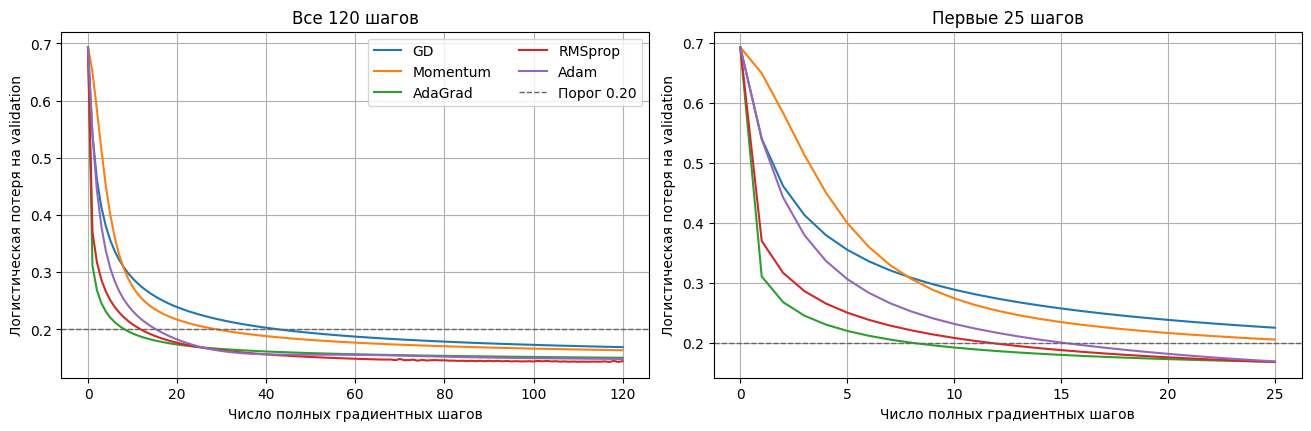

In [63]:
def logistic_loss(A, y_pm, w):
    return np.logaddexp(0, -y_pm * (A @ w)).mean()

def train_optimizer(method, eta, steps=120):
    w = np.zeros(A_train.shape[1])
    velocity = np.zeros_like(w)
    square_sum = np.zeros_like(w)
    mean_square = np.zeros_like(w)
    mean_grad = np.zeros_like(w)
    train_curve, valid_curve, weights = [], [], []
    for t in range(steps + 1):
        train_loss, grad = logistic_loss_grad(A_train, y_train_pm, w)
        train_curve.append(train_loss)
        valid_curve.append(logistic_loss(A_valid, y_valid_pm, w))
        weights.append(w.copy())
        if t == steps:
            break
        if method == 'GD':
            update = eta * grad
        elif method == 'Momentum':
            velocity = 0.8 * velocity + grad
            update = eta * velocity
        elif method == 'AdaGrad':
            square_sum += grad ** 2
            update = eta * grad / (np.sqrt(square_sum) + 1e-8)
        elif method == 'RMSprop':
            mean_square = 0.9 * mean_square + 0.1 * grad ** 2
            update = eta * grad / (np.sqrt(mean_square) + 1e-8)
        elif method == 'Adam':
            mean_grad = 0.9 * mean_grad + 0.1 * grad
            mean_square = 0.999 * mean_square + 0.001 * grad ** 2
            corrected_grad = mean_grad / (1 - 0.9 ** (t + 1))
            corrected_square = mean_square / (1 - 0.999 ** (t + 1))
            update = eta * corrected_grad / (np.sqrt(corrected_square) + 1e-8)
        else:
            raise ValueError(method)
        w = w - update
    return {'train': np.array(train_curve), 'valid': np.array(valid_curve),
            'weights': np.array(weights)}

# Размеры eta отличаются: правила обновления по-разному масштабируют градиент.
method_eta = {'GD': 0.2, 'Momentum': 0.05, 'AdaGrad': 0.15,
              'RMSprop': 0.03, 'Adam': 0.03}
results = {name: train_optimizer(name, eta) for name, eta in method_eta.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), layout='constrained')
for name, result in results.items():
    axes[0].plot(result['valid'], label=name)
    axes[1].plot(np.arange(26), result['valid'][:26], label=name)
for ax, title in zip(axes, ['Все 120 шагов', 'Первые 25 шагов']):
    ax.axhline(0.20, color='0.4', ls='--', lw=1, label='Порог 0.20')
    ax.set(xlabel='Число полных градиентных шагов',
           ylabel='Логистическая потеря на validation', title=title)
axes[0].legend(ncol=2)
plt.show()

На графиках выше видно, как уменьшается loss на validation. Пунктирная линия $0.20$ служит одним и тем же ориентиром для всех методов. Число шагов до неё показывает **скорость снижения потери в этом опыте**. Каждый шаг использует полный градиент по train. Значения $\eta$ у методов разные, потому что правила обновления по-разному масштабируют градиент.

Итоговый рисунок ниже отвечает ещё на один вопрос: **сколько писем классифицировано неверно**. Для каждого метода берём веса в точке с наименьшей validation loss и один раз проверяем их на 921 письме test. Синим показаны обычные письма, ошибочно отправленные в спам, оранжевым показан пропущенный спам. Сумма двух частей полосы равна числу ошибок. Сравнивайте верхний и нижний графики отдельно: быстрый спад loss сам по себе не гарантирует меньшего числа ошибок.

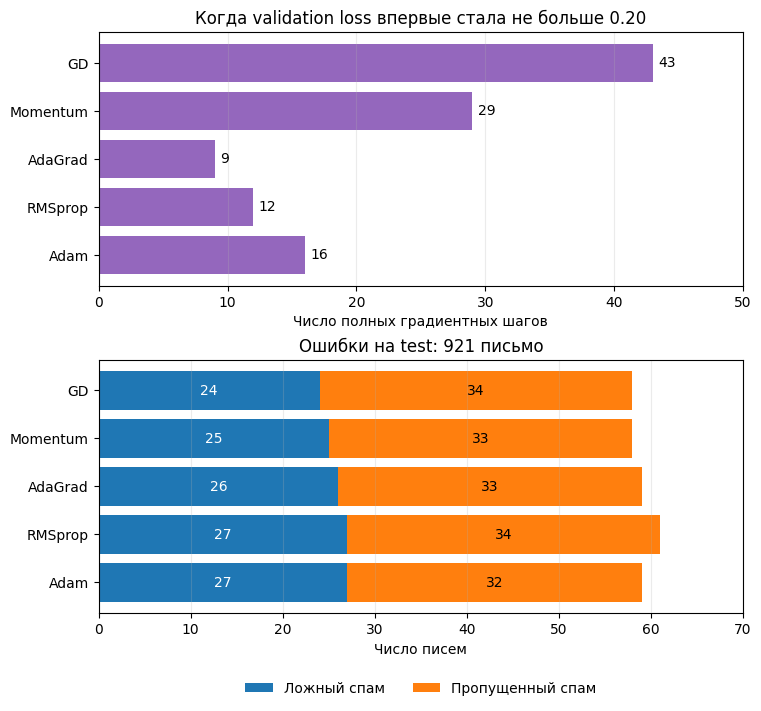

In [64]:
method_names = list(results)
steps_to_target = []
false_spam = []
missed_spam = []

for name in method_names:
    result = results[name]
    reached = np.flatnonzero(result['valid'] <= 0.20)
    steps_to_target.append(int(reached[0]) if len(reached) else np.nan)
    best_step = int(np.argmin(result['valid']))
    predictions = (A_test @ result['weights'][best_step] >= 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions, labels=[0, 1]).ravel()
    false_spam.append(int(fp))
    missed_spam.append(int(fn))

fig, axes = plt.subplots(2, 1, figsize=(7.5, 7), layout='constrained')
bars = axes[0].barh(method_names, steps_to_target, color='tab:purple')
axes[0].bar_label(bars, padding=4)
axes[0].invert_yaxis()
axes[0].set(xlim=(0, 50), xlabel='Число полных градиентных шагов',
            title='Когда validation loss впервые стала не больше 0.20')

left = axes[1].barh(method_names, false_spam, color='tab:blue', label='Ложный спам')
right = axes[1].barh(method_names, missed_spam, left=false_spam,
                     color='tab:orange', label='Пропущенный спам')
axes[1].bar_label(left, label_type='center', color='white')
axes[1].bar_label(right, label_type='center', color='black')
axes[1].invert_yaxis()
axes[1].set(xlim=(0, 70), xlabel='Число писем',
            title=f'Ошибки на test: {len(y_test)} письмо')
axes[1].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.22), frameon=False)
for ax in axes:
    ax.grid(axis='x', alpha=0.25)
    ax.grid(axis='y', visible=False)
plt.show()

## Что получилось на письмах

**Скорость.** На верхнем графике AdaGrad дошёл до выбранного уровня validation loss за 9 полных шагов, GD за 43. Это сравнение при показанных настройках $\eta$ и одном разбиении данных.

**Ошибки.** На 921 письме test методы ошиблись 58–61 раз: GD и Momentum по 58, AdaGrad и Adam по 59, RMSprop 61. Их accuracy лежит от 0.934 до 0.937. Разница между крайними результатами составляет три письма. По этому опыту нельзя уверенно предпочесть один оптимизатор по accuracy. Если ложное попадание обычного письма в спам особенно дорого, сравнивать нужно также синие части полос, а не только общее число ошибок.

Данные: Hopkins, Reeber, Forman, Suermondt, [Spambase, UCI Machine Learning Repository](https://doi.org/10.24432/C53G6X), 1999, CC BY 4.0. Исходный [семинар ВШЭ](https://github.com/nadiinchi/HSE_FCS_seminars/blob/master/materials/Seminar4.ipynb) использован как источник прикладной задачи со спамом.